In [1]:
from google.colab import files

In [ ]:
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d gsagar12/dspp1

In [ ]:
!unzip dspp1.zip

In [6]:
import pandas as pd

In [7]:
customers = pd.read_csv('customer_info.csv')
subscriptions = pd.read_csv('customer_product.csv')
products = pd.read_csv('product_info.csv')
cases = pd.read_csv('customer_cases.csv')

In [8]:
customers.columns

Index(['Unnamed: 0', 'customer_id', 'age', 'gender'], dtype='object')

In [9]:
subscriptions.columns

Index(['Unnamed: 0', 'customer_id', 'product', 'signup_date_time',
       'cancel_date_time'],
      dtype='object')

In [10]:
products.columns

Index(['product_id', 'name', 'price', 'billing_cycle'], dtype='object')

In [11]:
cases.columns

Index(['Unnamed: 0', 'case_id', 'date_time', 'customer_id', 'channel',
       'reason'],
      dtype='object')

In [12]:
customers.head()

,Unnamed: 0,customer_id,age,gender
0,1,C2448,76,female
1,2,C2449,61,male
2,3,C2450,58,female
3,4,C2451,62,female
4,5,C2452,71,male


In [13]:
products.head()

,product_id,name,price,billing_cycle
0,prd_1,annual_subscription,1200,12
1,prd_2,monthly_subscription,125,1


In [14]:
subscriptions.head()

,Unnamed: 0,customer_id,product,signup_date_time,cancel_date_time
0,1,C2448,prd_1,2017-01-01 10:35:09,NaN
1,2,C2449,prd_1,2017-01-01 11:39:29,2021-09-05 10:00:02
2,3,C2450,prd_1,2017-01-01 11:42:00,2019-01-13 16:24:55
3,4,C2451,prd_2,2017-01-01 13:32:08,NaN
4,5,C2452,prd_1,2017-01-01 13:57:30,2021-06-28 18:06:01


Dropping the Unnamed column in the Subscriptions, Cases and Customers data

In [15]:
for df in [subscriptions, cases, customers]:
    df.drop(columns=[col for col in df.columns if 'Unnamed' in col], inplace=True)


In [16]:
import pandas as pd
subscriptions.dtypes

,0
customer_id,object
product,object
signup_date_time,object
cancel_date_time,object


In [17]:
subscriptions['signup_date_time']=pd.to_datetime(subscriptions['signup_date_time'])
subscriptions['cancel_date_time']=pd.to_datetime(subscriptions['cancel_date_time'])


In [18]:
subscriptions.dtypes

,0
customer_id,object
product,object
signup_date_time,datetime64[ns]
cancel_date_time,datetime64[ns]


Removing Time Stamp and Extracting the Date in Year-Month-Date Format

In [19]:
subscriptions['signup_date_time'] = subscriptions['signup_date_time'].dt.strftime('%Y-%m-%d')
subscriptions['cancel_date_time'] = subscriptions['cancel_date_time'].dt.strftime('%Y-%m-%d')

In [20]:
subscriptions.head()

,customer_id,product,signup_date_time,cancel_date_time
0,C2448,prd_1,2017-01-01,NaN
1,C2449,prd_1,2017-01-01,2021-09-05
2,C2450,prd_1,2017-01-01,2019-01-13
3,C2451,prd_2,2017-01-01,NaN
4,C2452,prd_1,2017-01-01,2021-06-28


In [21]:
subscriptions['cancel_date_time'].isna().sum()

np.int64(396447)

In [22]:
subscriptions.dtypes

,0
customer_id,object
product,object
signup_date_time,object
cancel_date_time,object


In [23]:
subscriptions['signup_date_time']=pd.to_datetime(subscriptions['signup_date_time'])
subscriptions['cancel_date_time']=pd.to_datetime(subscriptions['cancel_date_time'])

In [24]:
subscriptions.head()

,customer_id,product,signup_date_time,cancel_date_time
0,C2448,prd_1,2017-01-01,NaT
1,C2449,prd_1,2017-01-01,2021-09-05
2,C2450,prd_1,2017-01-01,2019-01-13
3,C2451,prd_2,2017-01-01,NaT
4,C2452,prd_1,2017-01-01,2021-06-28


In [25]:
customers.head()


,customer_id,age,gender
0,C2448,76,female
1,C2449,61,male
2,C2450,58,female
3,C2451,62,female
4,C2452,71,male


Understanding Customer demographics

In [26]:
print((customers['gender'] == 'female').sum())
print((customers['gender'] == 'male').sum())

199002
309930


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipython-input-760475962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='gender', data=customers,  palette='Set2', width=0.25)


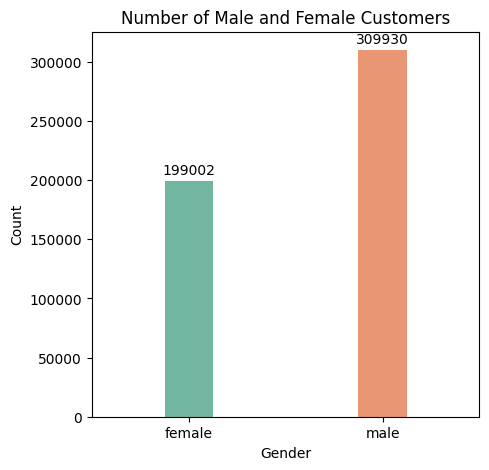

In [28]:
plt.figure(figsize=(5, 5))
ax=sns.countplot(x='gender', data=customers,  palette='Set2', width=0.25)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.title('Number of Male and Female Customers')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Age Distribution

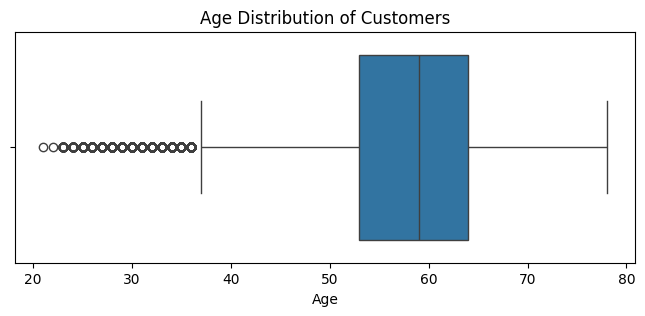

In [29]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=customers['age'])
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.show()

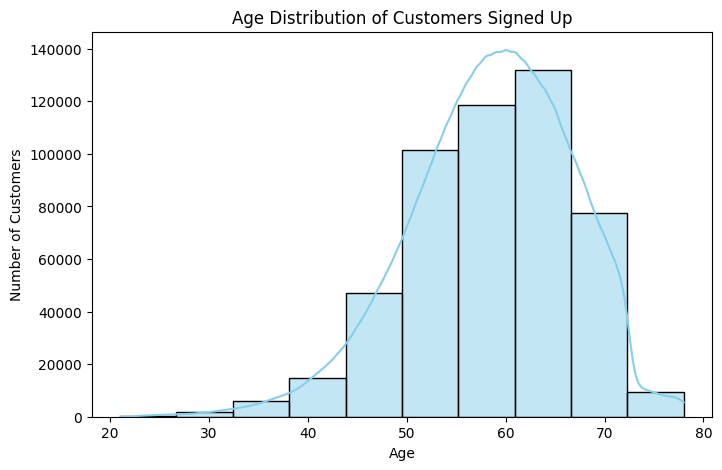

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(customers['age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution of Customers Signed Up')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

Understanding Cases Data

In [31]:
cases.head()

,case_id,date_time,customer_id,channel,reason
0,CC101,2017-01-01 10:32:03,C2448,phone,signup
1,CC102,2017-01-01 11:35:47,C2449,phone,signup
2,CC103,2017-01-01 11:37:09,C2450,phone,signup
3,CC104,2017-01-01 13:28:14,C2451,phone,signup
4,CC105,2017-01-01 13:52:22,C2452,phone,signup


Trend Analysis - cases per month and cases per year

In [32]:
cases_analysis = cases.copy()

In [33]:
cases_analysis['date_time'] = pd.to_datetime(cases_analysis['date_time'])


In [34]:
cases_analysis['year'] = cases_analysis['date_time'].dt.year
cases_analysis['month'] = cases_analysis['date_time'].dt.to_period('M')
cases_analysis['day'] = cases_analysis['date_time'].dt.date
cases_analysis['hour'] = cases_analysis['date_time'].dt.hour
cases_analysis['day_of_week'] = cases_analysis['date_time'].dt.day_name()

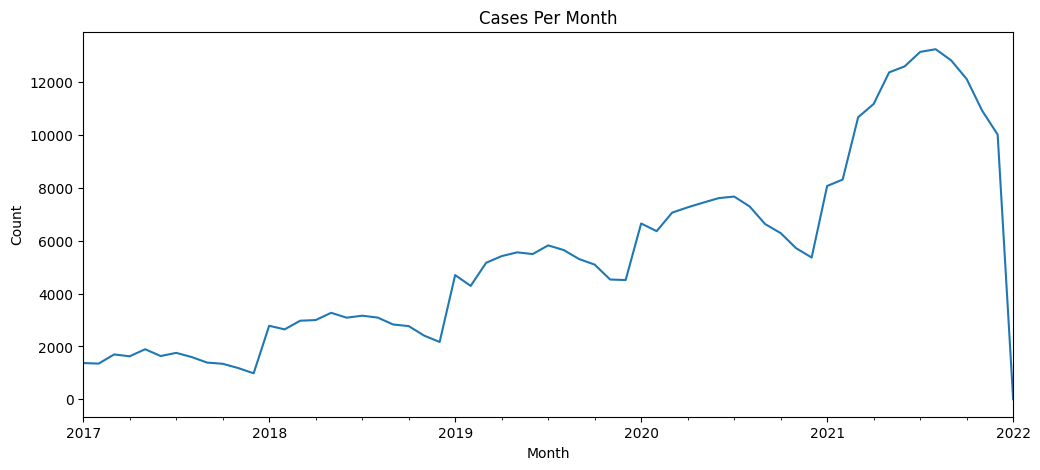

In [35]:
cases_per_month = cases_analysis.groupby('month').size()
plt.figure(figsize=(12,5))
cases_per_month.plot(kind='line')
plt.title("Cases Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

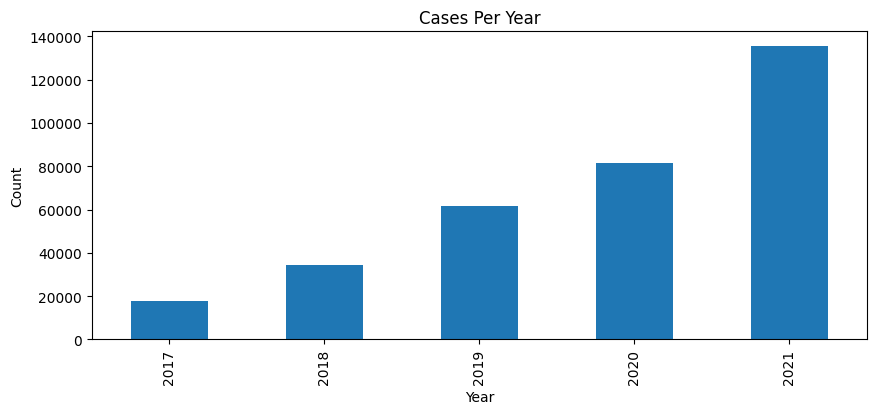

In [36]:
cases_analysis_2021 = cases_analysis[cases_analysis['year'] < 2022]
cases_per_year = cases_analysis_2021.groupby('year').size()
plt.figure(figsize=(10,4))
cases_per_year.plot(kind='bar')
plt.title("Cases Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


Channel Analysis

Channel Distribution

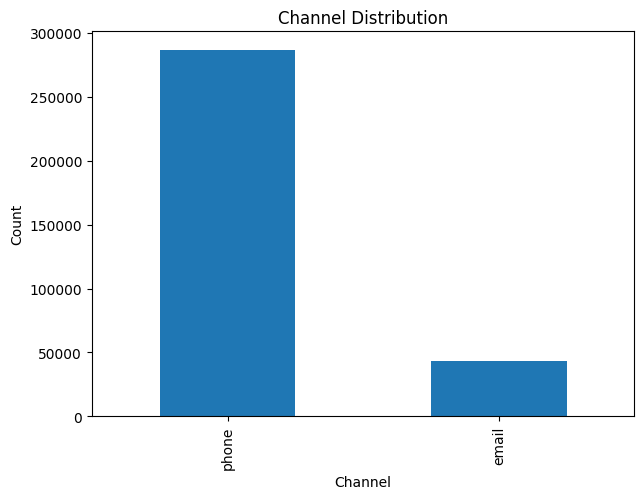

In [37]:
plt.figure(figsize=(7,5))
cases_analysis['channel'].value_counts().plot(kind='bar')
plt.title("Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.show()

Trend of Channel Over Time


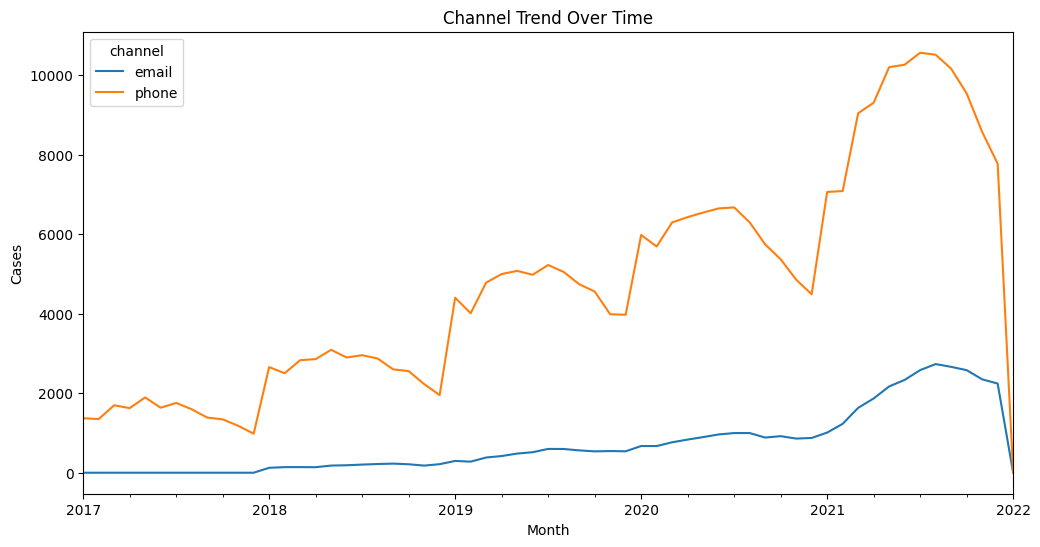

In [38]:
channel_trend = cases_analysis.groupby(['month', 'channel']).size().unstack().fillna(0)
channel_trend.plot(figsize=(12,6))
plt.title("Channel Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Cases")
plt.show()

Reason Analysis : Frequency of Reasons


/tmp/ipython-input-3149334538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='reason', data=cases_analysis, palette='Set2')


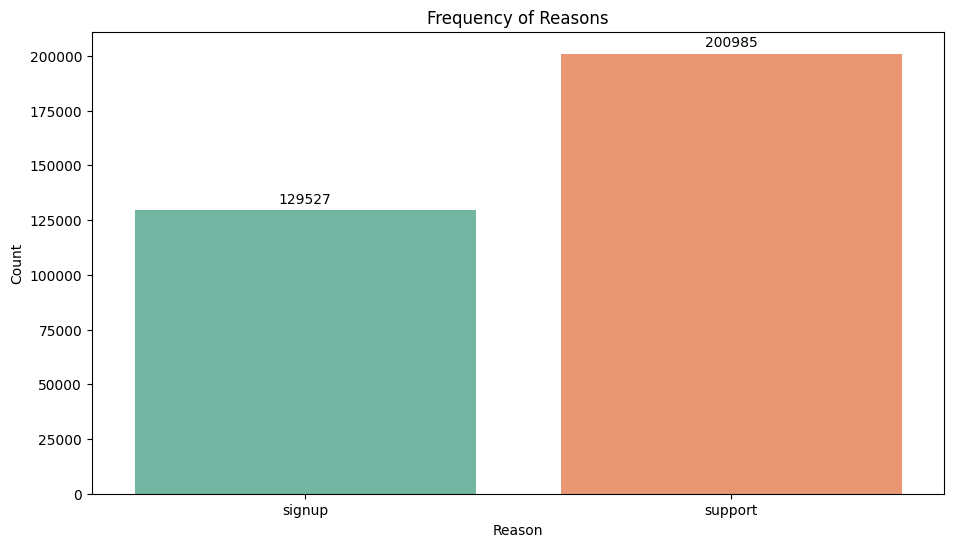

In [39]:
plt.figure(figsize=(11,6))
ax = sns.countplot(x='reason', data=cases_analysis, palette='Set2')
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8), textcoords='offset points'
    )
plt.title('Frequency of Reasons')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.show()

Reason and Channel Heatmap

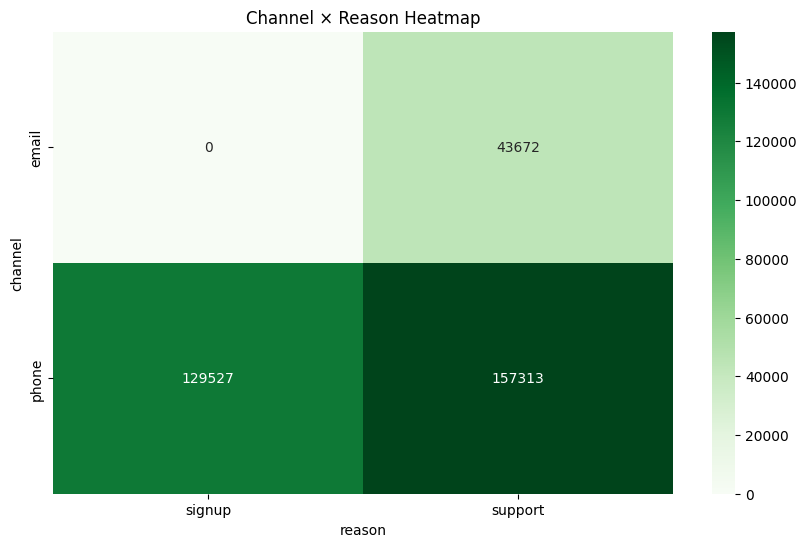

In [40]:
heatmap2 = cases_analysis.groupby(['channel', 'reason']).size().unstack().fillna(0)
plt.figure(figsize=(10,6))
sns.heatmap(heatmap2, annot=True, fmt='g', cmap='Greens')
plt.title("Channel × Reason Heatmap")
plt.show()

Trend of Customer Channel preferences over time

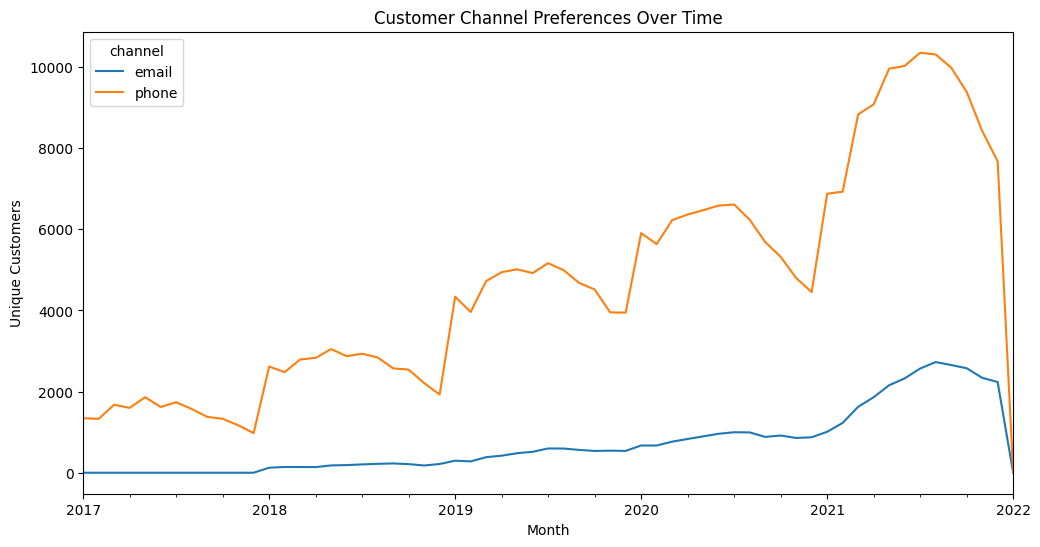

In [41]:
cust_channel_trend = cases_analysis.groupby(['month', 'channel'])['customer_id'].nunique().unstack().fillna(0)
cust_channel_trend.plot(figsize=(12,6))
plt.title("Customer Channel Preferences Over Time")
plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.show()

Merging Subscriptions, Customers and Products

In [42]:
subscriptions = subscriptions.merge(products[['product_id', 'name']],
                             left_on='product',
                             right_on='product_id',
                             how='left')

In [43]:
subscriptions=subscriptions[['customer_id','name','signup_date_time','cancel_date_time']]

In [44]:
subscriptions.rename(columns={'name': 'product_type'}, inplace=True)

In [45]:
subscriptions = subscriptions.merge(
    customers[['customer_id', 'age', 'gender']],
    on='customer_id',
    how='left'
)

In [46]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender
0,C2448,annual_subscription,2017-01-01,NaT,76,female
1,C2449,annual_subscription,2017-01-01,2021-09-05,61,male
2,C2450,annual_subscription,2017-01-01,2019-01-13,58,female
3,C2451,monthly_subscription,2017-01-01,NaT,62,female
4,C2452,annual_subscription,2017-01-01,2021-06-28,71,male


Understanding Annual and Monthly Subscriptions Distribution

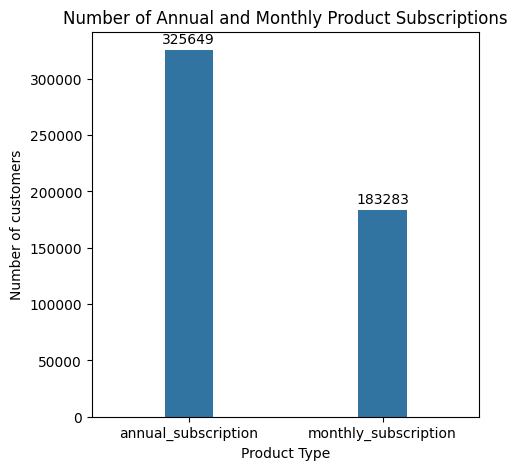

In [47]:
plt.figure(figsize=(5, 5))
ax=sns.countplot(x='product_type', data=subscriptions, width=0.25)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.title('Number of Annual and Monthly Product Subscriptions')
plt.xlabel('Product Type')
plt.ylabel('Number of customers')
plt.show()

In [48]:
subscriptions['year'] = subscriptions['signup_date_time'].dt.year


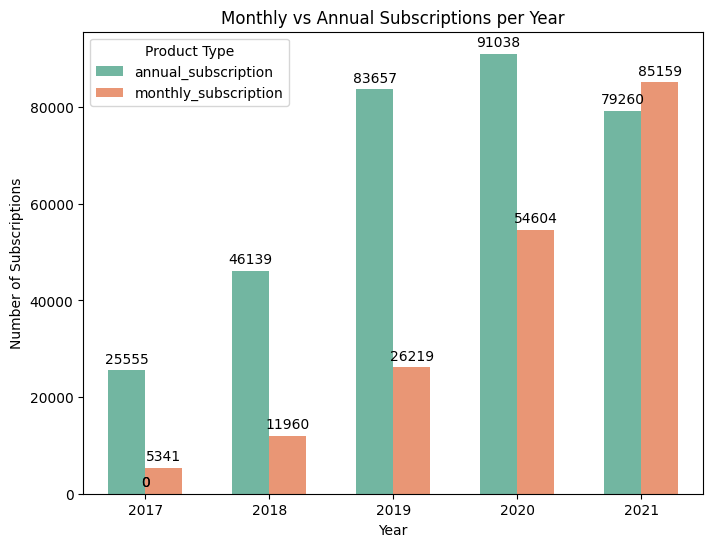

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax=sns.countplot(x='year', hue='product_type', data=subscriptions, palette='Set2', width=0.6)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.title('Monthly vs Annual Subscriptions per Year')
plt.xlabel('Year')
plt.ylabel('Number of Subscriptions')
plt.legend(title='Product Type')
plt.show()


Understanding Subscription Cancellations:

In [50]:
subscriptions['is_cancelled'] = subscriptions['cancel_date_time'].notna().astype(int)

In [51]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled
0,C2448,annual_subscription,2017-01-01,NaT,76,female,2017,0
1,C2449,annual_subscription,2017-01-01,2021-09-05,61,male,2017,1
2,C2450,annual_subscription,2017-01-01,2019-01-13,58,female,2017,1
3,C2451,monthly_subscription,2017-01-01,NaT,62,female,2017,0
4,C2452,annual_subscription,2017-01-01,2021-06-28,71,male,2017,1


Overall Cancellations Rate

In [52]:
overall_cancellation_rate = subscriptions['is_cancelled'].mean() * 100
overall_cancellation_rate

np.float64(22.102166890665156)

Cancellations per year

In [53]:
subscriptions['cancel_year'] = subscriptions['cancel_date_time'].dt.year.astype('Int64')

In [54]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled,cancel_year
0,C2448,annual_subscription,2017-01-01,NaT,76,female,2017,0,<NA>
1,C2449,annual_subscription,2017-01-01,2021-09-05,61,male,2017,1,2021
2,C2450,annual_subscription,2017-01-01,2019-01-13,58,female,2017,1,2019
3,C2451,monthly_subscription,2017-01-01,NaT,62,female,2017,0,<NA>
4,C2452,annual_subscription,2017-01-01,2021-06-28,71,male,2017,1,2021


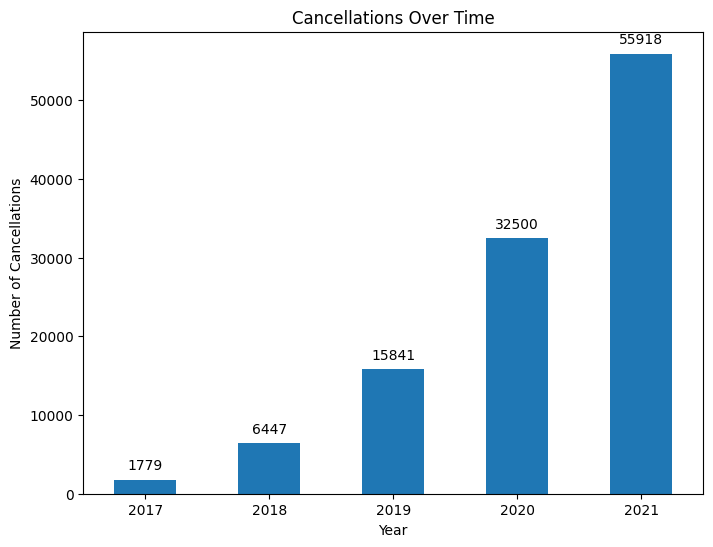

In [55]:
no_of_cancellations = subscriptions.dropna(subset=['cancel_date_time'])['cancel_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))
ax = no_of_cancellations.plot(kind='bar')
plt.title("Cancellations Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cancellations")
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', xytext=(0,5), textcoords='offset points'
    )
plt.xticks(rotation=0)
plt.show()

Age and Cancellations

In [56]:
subscriptions['age_bins'] = pd.cut(
    subscriptions['age'],
    bins=[0,30,40,50,60,70,100],
    labels=['<30','30-40','40-50','50-60','60-70','70+']
)

/tmp/ipython-input-624200168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancelled_rate_by_age = subscriptions.groupby('age_bins')['is_cancelled'].mean() * 100


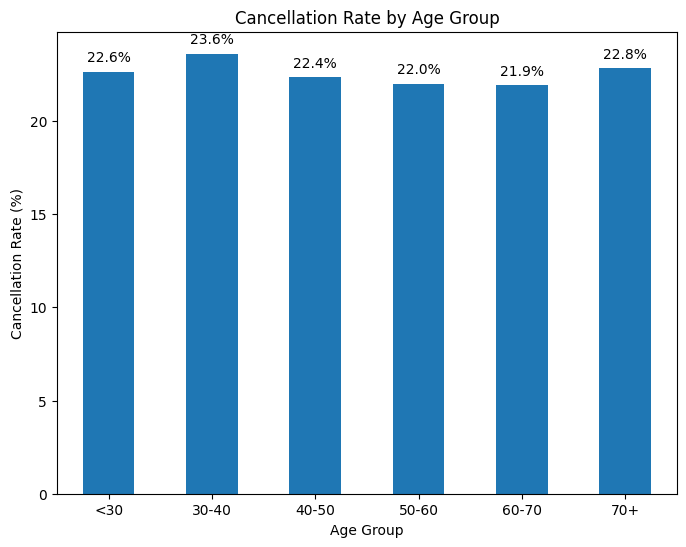

In [57]:
cancelled_rate_by_age = subscriptions.groupby('age_bins')['is_cancelled'].mean() * 100

plt.figure(figsize=(8,6))
ax = cancelled_rate_by_age.plot(kind='bar')
plt.title("Cancellation Rate by Age Group")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Age Group")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', xytext=(0,5), textcoords='offset points'
    )
plt.xticks(rotation=0)
plt.show()

Gender vs Cancellations

In [58]:
cancellation_rate_by_gender = subscriptions.groupby('gender')['is_cancelled'].mean() * 100
cancellation_rate_by_gender

,is_cancelled
gender,
female,22.225405
male,22.023037


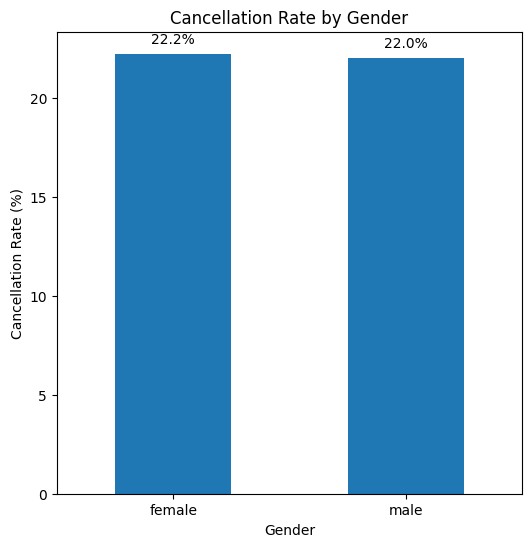

In [59]:
plt.figure(figsize=(6,6))
ax = cancellation_rate_by_gender.plot(kind='bar')
plt.title("Cancellation Rate by Gender")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Gender")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', xytext=(0,5), textcoords='offset points'
    )
plt.xticks(rotation=0)
plt.show()

Cancellation vs Product type

In [60]:
cancellations_by_pt = subscriptions.groupby('product_type')['is_cancelled'].mean() * 100
cancellations_by_pt

,is_cancelled
product_type,
annual_subscription,21.397885
monthly_subscription,23.353503


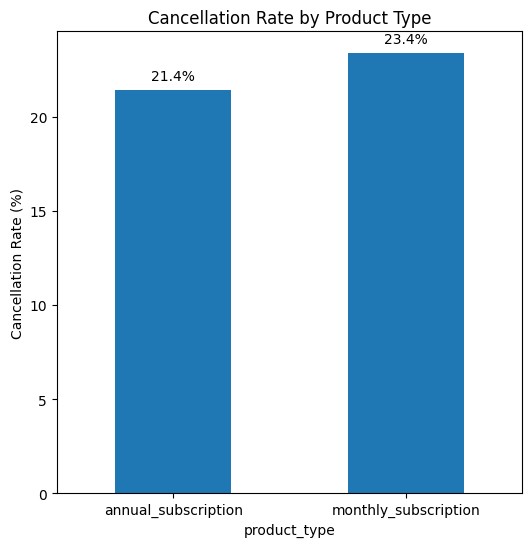

In [61]:
plt.figure(figsize=(6,6))
ax = cancellations_by_pt.plot(kind='bar')
plt.title("Cancellation Rate by Product Type")
plt.ylabel("Cancellation Rate (%)")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', xytext=(0,5), textcoords='offset points'
    )
plt.xticks(rotation=0)
plt.show()

Heat Map: Cancellation Rate x Product Type x Gender

In [62]:
pivot = subscriptions.pivot_table(
    values='is_cancelled',
    index='gender',
    columns='product_type',
    aggfunc='mean'
)

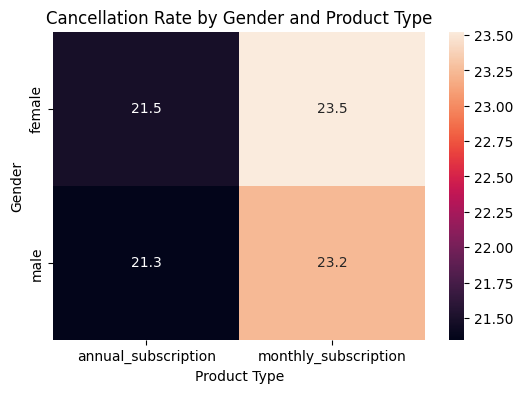

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(pivot * 100, annot=True, fmt=".1f")
plt.title("Cancellation Rate by Gender and Product Type")
plt.ylabel("Gender")
plt.xlabel("Product Type")
plt.show()

Model Building

In [64]:
cases.head()

,case_id,date_time,customer_id,channel,reason
0,CC101,2017-01-01 10:32:03,C2448,phone,signup
1,CC102,2017-01-01 11:35:47,C2449,phone,signup
2,CC103,2017-01-01 11:37:09,C2450,phone,signup
3,CC104,2017-01-01 13:28:14,C2451,phone,signup
4,CC105,2017-01-01 13:52:22,C2452,phone,signup


Identifying frequency of support cases for each customer

In [65]:
support_cases_count = cases.groupby('customer_id').size().reset_index(name='support_cases_count')
support_cases_count

,customer_id,support_cases_count
0,C10000,2
1,C100000,2
2,C100001,1
3,C100002,1
4,C100003,1
...,...,...
258655,C99995,2
258656,C99996,2
258657,C99997,3
258658,C99998,1


In [66]:
subscriptions = subscriptions.merge(support_cases_count, on='customer_id', how='left')

In [67]:
subscriptions['support_cases_count'] = subscriptions['support_cases_count'].fillna(0).astype(int)

In [68]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled,cancel_year,age_bins,support_cases_count
0,C2448,annual_subscription,2017-01-01,NaT,76,female,2017,0,<NA>,70+,1
1,C2449,annual_subscription,2017-01-01,2021-09-05,61,male,2017,1,2021,60-70,1
2,C2450,annual_subscription,2017-01-01,2019-01-13,58,female,2017,1,2019,50-60,1
3,C2451,monthly_subscription,2017-01-01,NaT,62,female,2017,0,<NA>,60-70,2
4,C2452,annual_subscription,2017-01-01,2021-06-28,71,male,2017,1,2021,70+,1


In [69]:
products.head()

,product_id,name,price,billing_cycle
0,prd_1,annual_subscription,1200,12
1,prd_2,monthly_subscription,125,1


In [70]:
subscriptions = subscriptions.merge(products, left_on='product_type', right_on='name', how='left')

In [71]:
subscriptions = subscriptions.drop(columns=['name'])

In [72]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled,cancel_year,age_bins,support_cases_count,product_id,price,billing_cycle
0,C2448,annual_subscription,2017-01-01,NaT,76,female,2017,0,<NA>,70+,1,prd_1,1200,12
1,C2449,annual_subscription,2017-01-01,2021-09-05,61,male,2017,1,2021,60-70,1,prd_1,1200,12
2,C2450,annual_subscription,2017-01-01,2019-01-13,58,female,2017,1,2019,50-60,1,prd_1,1200,12
3,C2451,monthly_subscription,2017-01-01,NaT,62,female,2017,0,<NA>,60-70,2,prd_2,125,1
4,C2452,annual_subscription,2017-01-01,2021-06-28,71,male,2017,1,2021,70+,1,prd_1,1200,12


Label Encoding : Female = 0, Male = 1

In [73]:
from sklearn.preprocessing import LabelEncoder
subscriptions['gender'] = LabelEncoder().fit_transform(subscriptions['gender'])

Label Encoding: Annually = 0, Monthly = 1

In [74]:
subscriptions['product_type'] = LabelEncoder().fit_transform(subscriptions['product_type'])

In [75]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled,cancel_year,age_bins,support_cases_count,product_id,price,billing_cycle
0,C2448,0,2017-01-01,NaT,76,0,2017,0,<NA>,70+,1,prd_1,1200,12
1,C2449,0,2017-01-01,2021-09-05,61,1,2017,1,2021,60-70,1,prd_1,1200,12
2,C2450,0,2017-01-01,2019-01-13,58,0,2017,1,2019,50-60,1,prd_1,1200,12
3,C2451,1,2017-01-01,NaT,62,0,2017,0,<NA>,60-70,2,prd_2,125,1
4,C2452,0,2017-01-01,2021-06-28,71,1,2017,1,2021,70+,1,prd_1,1200,12


In [76]:
subscriptions.dtypes

,0
customer_id,object
product_type,int64
signup_date_time,datetime64[ns]
cancel_date_time,datetime64[ns]
age,int64
gender,int64
year,int32
is_cancelled,int64
cancel_year,Int64
age_bins,category


Filling the cancel date as end of the year date for null values to caluculate Tenure

In [77]:
last_date = pd.to_datetime('2022-12-31')
subscriptions['tenure_in_months'] = ((subscriptions['cancel_date_time'].fillna(last_date) -
                                      subscriptions['signup_date_time']) / pd.Timedelta(days=30)).astype(int)

Coorelation Matrix

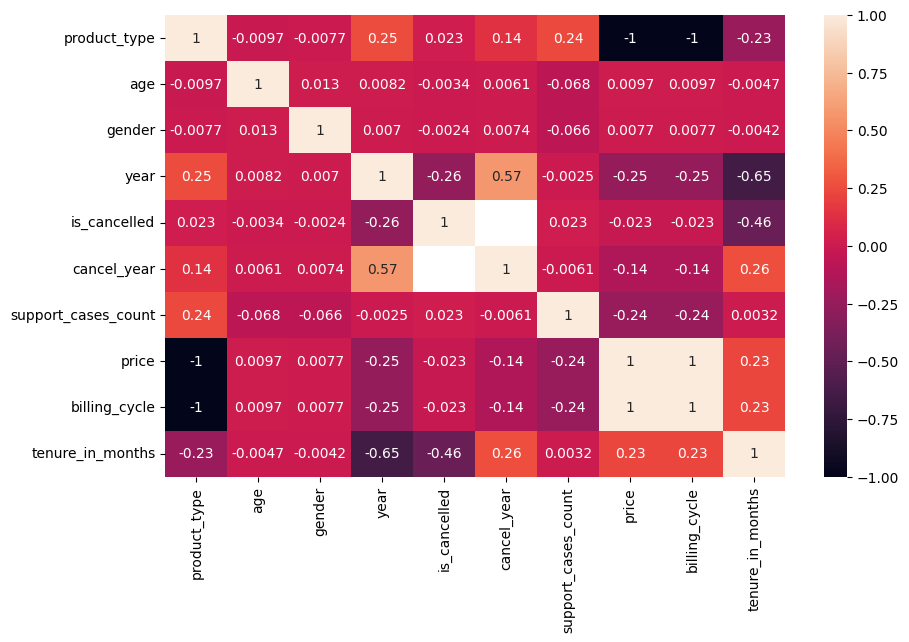

In [78]:
numeric_cols = subscriptions.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

In [79]:
subscriptions.head()

,customer_id,product_type,signup_date_time,cancel_date_time,age,gender,year,is_cancelled,cancel_year,age_bins,support_cases_count,product_id,price,billing_cycle,tenure_in_months
0,C2448,0,2017-01-01,NaT,76,0,2017,0,<NA>,70+,1,prd_1,1200,12,73
1,C2449,0,2017-01-01,2021-09-05,61,1,2017,1,2021,60-70,1,prd_1,1200,12,56
2,C2450,0,2017-01-01,2019-01-13,58,0,2017,1,2019,50-60,1,prd_1,1200,12,24
3,C2451,1,2017-01-01,NaT,62,0,2017,0,<NA>,60-70,2,prd_2,125,1,73
4,C2452,0,2017-01-01,2021-06-28,71,1,2017,1,2021,70+,1,prd_1,1200,12,54


In [80]:
subscriptions = subscriptions.drop(columns=['signup_date_time','cancel_date_time','age_bins','product_id', 'customer_id','year','cancel_year'])

In [81]:
subscriptions.head()

,product_type,age,gender,is_cancelled,support_cases_count,price,billing_cycle,tenure_in_months
0,0,76,0,0,1,1200,12,73
1,0,61,1,1,1,1200,12,56
2,0,58,0,1,1,1200,12,24
3,1,62,0,0,2,125,1,73
4,0,71,1,1,1,1200,12,54


Implementing the Light GBM Model

In [82]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [83]:
X = subscriptions.drop(columns=['is_cancelled'])
y = subscriptions['is_cancelled']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [85]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [86]:
print("Class distribution after SMOTE:\n", pd.Series(y_train_resampled).value_counts())


Class distribution after SMOTE:
 is_cancelled
0    317157
1    317157
Name: count, dtype: int64


In [87]:
param_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 600, 1000],
    'min_data_in_leaf': [20, 40, 60],
    'feature_fraction': [0.7, 0.9, 1.0],
    'bagging_fraction': [0.7, 0.9, 1.0],
    'lambda_l1': [0, 0.5, 1],
    'lambda_l2': [0, 1, 3]
}

In [88]:
lgbm_model = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    random_state=42
)

In [89]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_grid,
    n_iter=40,            # small but effective search
    scoring='accuracy',   # or f1, roc_auc
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [90]:
random_search.fit(X_train_resampled, y_train_resampled)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(objective='binary',
                                            random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'bagging_fraction': [0.7, 0.9, 1.0],
                                        'feature_fraction': [0.7, 0.9, 1.0],
                                        'lambda_l1': [0, 0.5, 1],
                                        'lambda_l2': [0, 1, 3],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 8],
                                        'min_data_in_leaf': [20, 40, 60],
                                        'n_estimators': [300, 600, 1000],
                                        'num_leaves': [15, 31, 63]},
                   random_state=42, scoring='accuracy', verbose=1)

In [91]:
best_params = random_search.best_params_
best_params

{'num_leaves': 63,
 'n_estimators': 600,
 'min_data_in_leaf': 60,
 'max_depth': -1,
 'learning_rate': 0.1,
 'lambda_l2': 1,
 'lambda_l1': 0,
 'feature_fraction': 1.0,
 'bagging_fraction': 0.9}

In [94]:
best_model = LGBMClassifier(**best_params)
best_model.fit(X_train_resampled, y_train_resampled)

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambd

LGBMClassifier(bagging_fraction=0.9, feature_fraction=1.0, lambda_l1=0,
               lambda_l2=1, min_data_in_leaf=60, n_estimators=600,
               num_leaves=63)

In [95]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9


In [96]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90     79290
           1       0.65      0.63      0.64     22497

    accuracy                           0.84    101787
   macro avg       0.77      0.77      0.77    101787
weighted avg       0.84      0.84      0.84    101787

ROC-AUC: 0.8467806346377217


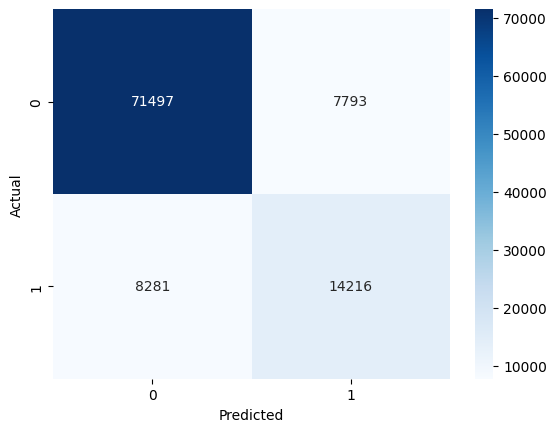

In [97]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

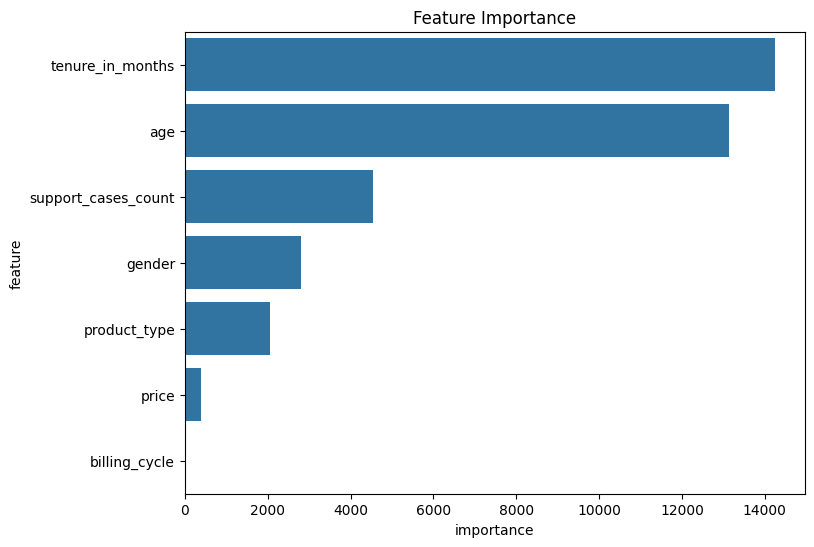

In [99]:
feature_imp = pd.DataFrame({
    'feature': X_train_resampled.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feature_imp)
plt.title("Feature Importance")
plt.show()

Dropping billing_cycle column

In [100]:
X_train_resampled = X_train_resampled.drop(columns=['billing_cycle'])

In [101]:
X_test = X_test.drop(columns=['billing_cycle'])

In [103]:
best_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    eval_metric='binary_logloss',
    callbacks= [early_stopping(stopping_rounds=50),log_evaluation(100)],
)

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambd

LGBMClassifier(bagging_fraction=0.9, feature_fraction=1.0, lambda_l1=0,
               lambda_l2=1, min_data_in_leaf=60, n_estimators=600,
               num_leaves=63)

In [104]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9


In [105]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8437816224075766
Confusion Matrix:
 [[71675  7615]
 [ 8286 14211]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90     79290
           1       0.65      0.63      0.64     22497

    accuracy                           0.84    101787
   macro avg       0.77      0.77      0.77    101787
weighted avg       0.84      0.84      0.84    101787



In [106]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']


In [107]:
cv_results = cross_validate(
    best_model,
    X_train_resampled,
    y_train_resampled,
    cv=skf,
    scoring=scoring,
    return_train_score=False
)

[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambd

In [108]:
for metric in scoring:
    print(f"{metric}: {np.mean(cv_results['test_' + metric]):.4f}")

accuracy: 0.7777
precision: 0.8674
recall: 0.6558
f1: 0.7469


The model achieved:
*   Test Accuracy: 0.84
*   Cross-Validation Accuracy: 0.77
*   Good precision for non-churn class and balanced precision–recall for churners
---

The difference between test accuracy and cross-validation accuracy indicates that the model performs well on new, unseen data and is not too overfitting.






In [109]:
!rm kaggle.json